# Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost



In [2]:

# Carga 
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

print(f"Train: {train.shape}  |  Test: {test.shape}")
train.head()

Train: (105000, 12)  |  Test: (45000, 11)


,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,9580,0.668999,58,2,0.449504,3425.0,9,1,1,1,1.0,0
1,39755,0.015922,71,0,6.000000,NaN,5,0,0,0,0.0,0
2,118799,0.183062,52,1,0.035593,5000.0,9,0,0,0,0.0,0
3,16489,0.162301,77,0,0.227886,2000.0,8,0,0,0,0.0,0
4,149857,0.404199,30,0,0.026010,5843.0,4,0,0,0,0.0,0


In [3]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(train, title='Prestamos Profiling Report')
# profile.to_file('prestamos_report.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 28.96it/s]


## 2. Análisis Exploratorio

In [4]:
# Variable objetivo: muy desbalanceada ---
# Dataset desbalanceado (~6.7% positivos). 

In [5]:
# Valores nulos ---
# MonthlyIncome has 20836 (19.8%) missing values
# NumberOfDependents has 2764 (2.6%) missing values

In [6]:
# Variables muy sesgadas. Muchos outliers:

# RevolvingUtilizationOfUnsecuredLines is highly skewed (γ1 = 72.30209845)	Skewed
# NumberOfTime30-59DaysPastDueNotWorse is highly skewed (γ1 = 23.32189059)	Skewed
# DebtRatio is highly skewed (γ1 = 86.99078467)	Skewed
# MonthlyIncome is highly skewed (γ1 = 111.0386965)	Skewed
# NumberOfTimes90DaysLate is highly skewed (γ1 = 23.85375002)	Skewed
# NumberOfTime60-89DaysPastDueNotWorse is highly skewed (γ1 = 24.12386029)

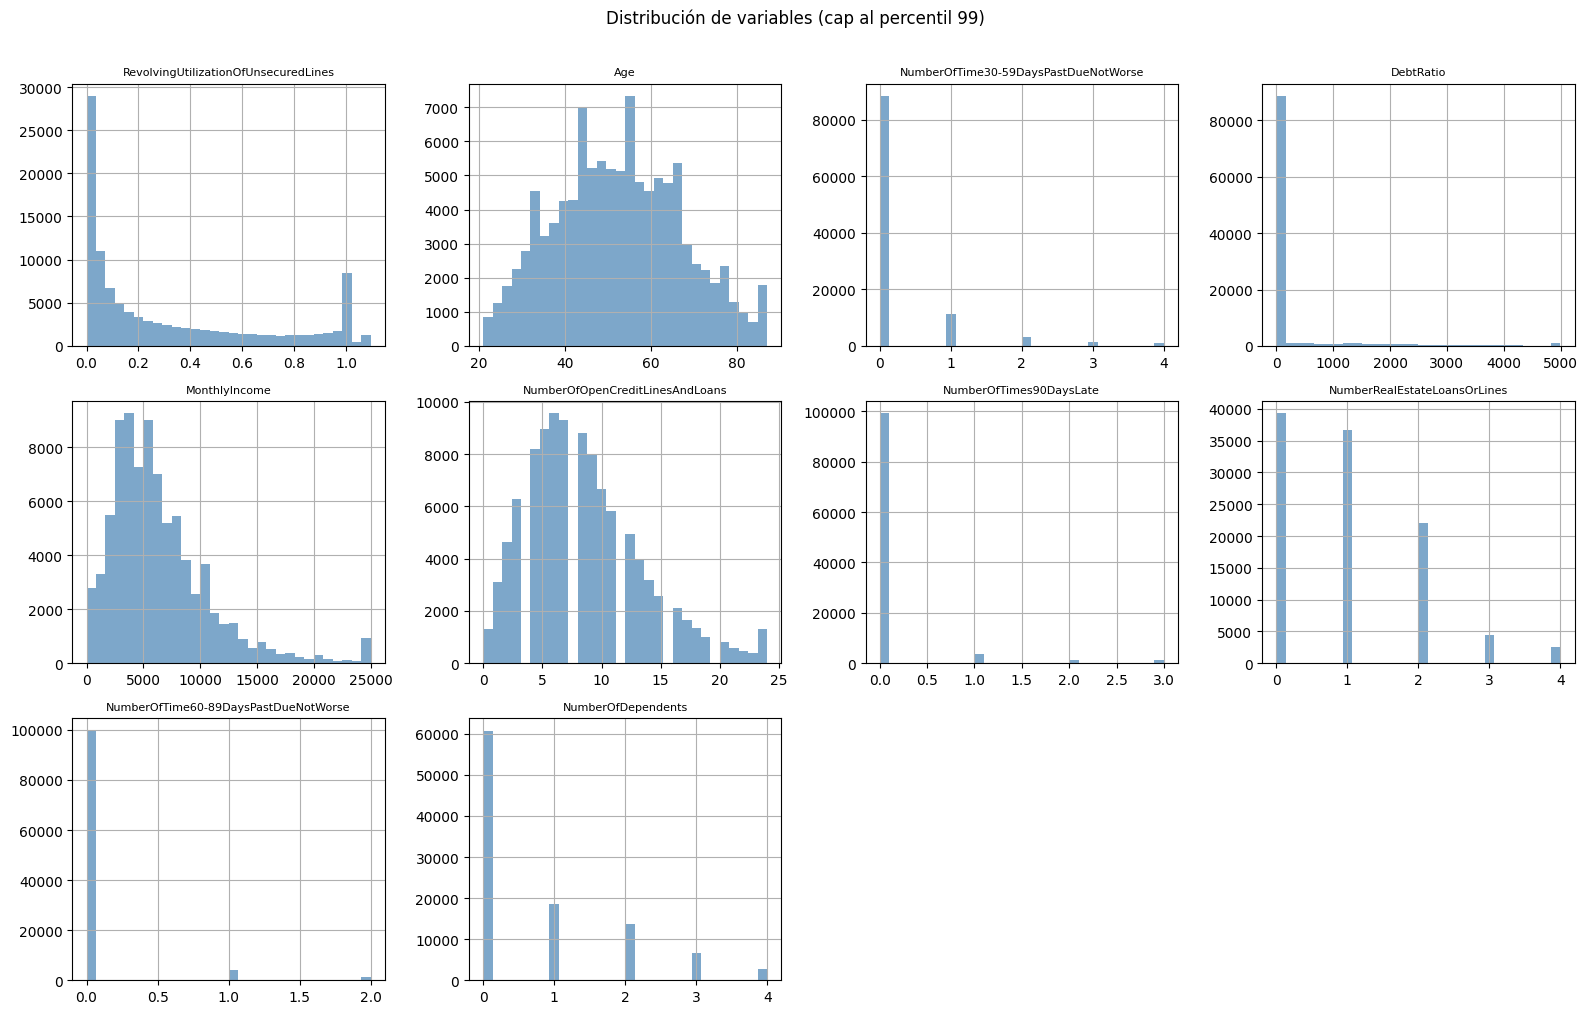

In [3]:
# --- 2.3 Distribución de features numéricas ---
features = [c for c in train.columns if c not in ['ID', 'SeriousDlqin2yrs']]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    train[col].clip(upper=train[col].quantile(0.99)).hist(ax=axes[i], bins=30, color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')
# Ocultar subplots sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribución de variables (cap al percentil 99)', y=1.01)
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'RevolvingUtilizationOfUnsecuredLines'),
  Text(1, 0, 'Age'),
  Text(2, 0, 'NumberOfTime30-59DaysPastDueNotWorse'),
  Text(3, 0, 'DebtRatio'),
  Text(4, 0, 'MonthlyIncome'),
  Text(5, 0, 'NumberOfOpenCreditLinesAndLoans'),
  Text(6, 0, 'NumberOfTimes90DaysLate'),
  Text(7, 0, 'NumberRealEstateLoansOrLines'),
  Text(8, 0, 'NumberOfTime60-89DaysPastDueNotWorse'),
  Text(9, 0, 'NumberOfDependents')])

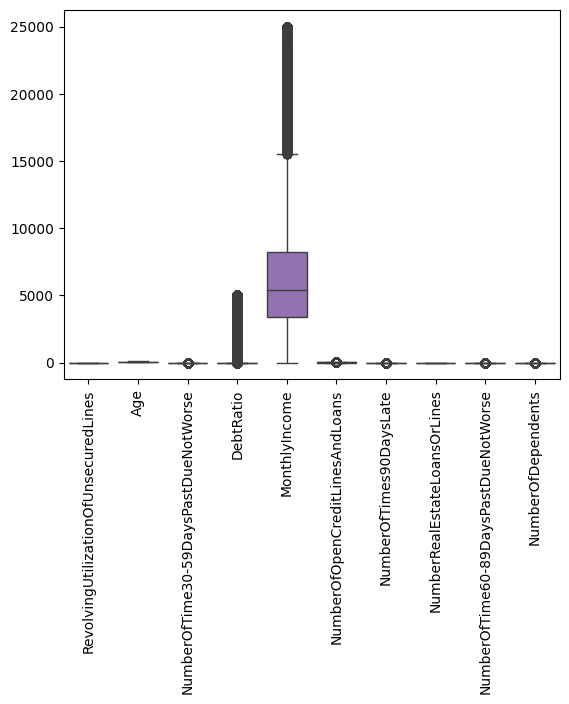

In [4]:
sns.boxplot(
    data=train[features].clip(upper=train[features].quantile(0.99), axis=1)
)
plt.xticks(rotation=90)

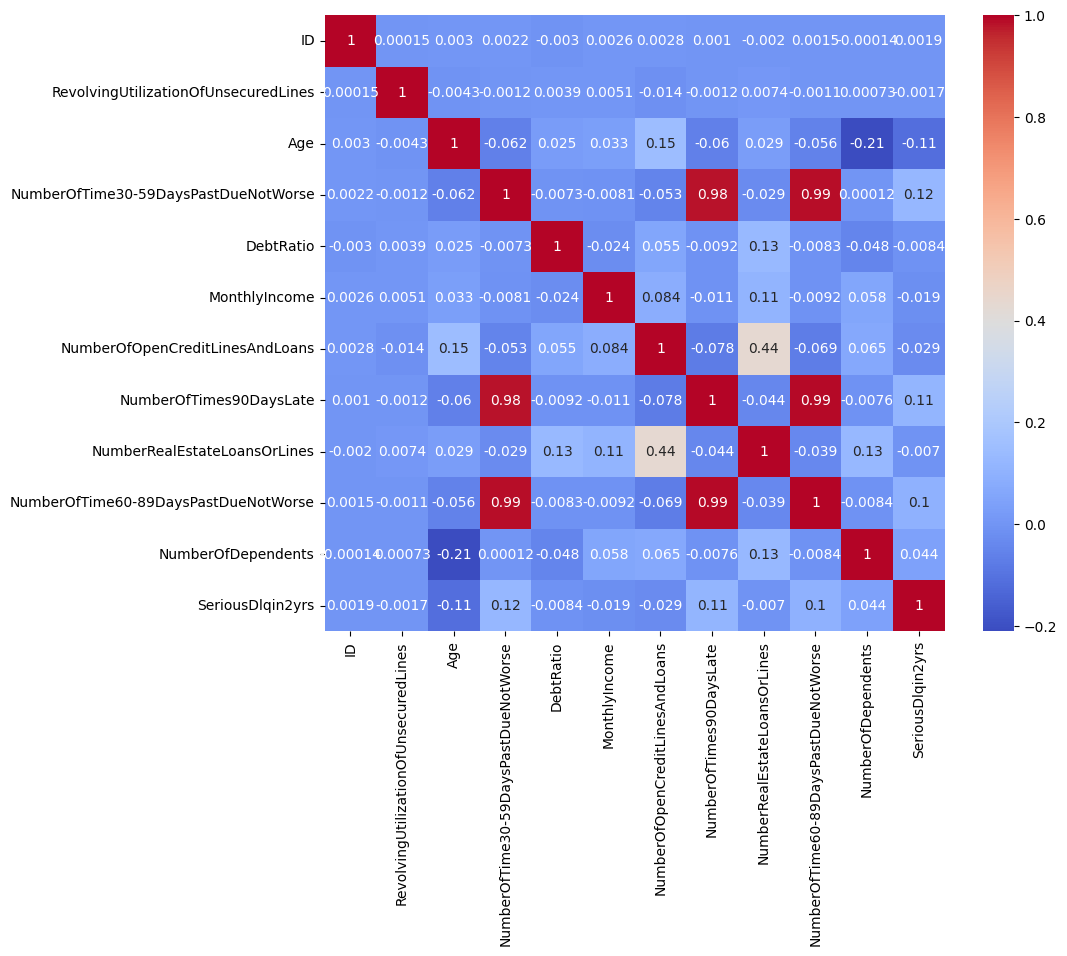

In [5]:
# --- 2.4 Correlación con el target ---
# corrs = train[features].corrwith(train['SeriousDlqin2yrs']).sort_values()
# fig, ax = plt.subplots(figsize=(7,4))
# corrs.plot(kind='barh', ax=ax, color=['coral' if v > 0 else 'steelblue' for v in corrs])
# ax.set_title('Correlación con SeriousDlqin2yrs')
# ax.axvline(0, color='black', lw=0.8)
# plt.tight_layout()
# plt.show()
# print("Variables más correlacionadas con impago (positivo = más riesgo):")
# print(corrs.sort_values(ascending=False).head(5))

plt.figure(figsize=(10, 8))
sns.heatmap (train.corr (numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## 3. Limpieza y Preprocesamiento

In [12]:
def preprocess(df, is_train=True):
    df = df.copy()

    # Eliminar features redundantes:'NumberOfTime30-59DaysPastDueNotWorse','NumberOfTimes90DaysLate',
    # 'NumberOfTime60-89DaysPastDueNotWorse' tienen  correlaciones de casi uno. 
    # Me quedo con la que más correlación tiene con el target: 'NumberOfTime30-59DaysPastDueNotWorse'

    # CAGADA. Dejándolos mejora mucho el modelo. Aunque estaban super correlacionadas eran las que más influian
    df = df.drop (columns=['NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse'])
    # 
    # --- Tratar outliers en columnas de retrasos ---

    # Hay valores 98 que son errores
    df['NumberOfTime30-59DaysPastDueNotWorse'] = df['NumberOfTime30-59DaysPastDueNotWorse'].replace(98, np.nan)  # tratar como nulo
    df['NumberOfTime30-59DaysPastDueNotWorse'] = df['NumberOfTime30-59DaysPastDueNotWorse'].fillna(df['NumberOfTime30-59DaysPastDueNotWorse'].median())

    # --- Rellenar nulos. No los puedo quitar porque no puedo quitar muestras del test ---
    # MonthlyIncome: mediana (distribución muy sesgada)
    df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
    # NumberOfDependents: mediana
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

    # --- Capar  outliers extremos ---
    # RevolvingUtilization puede ser > 1 (uso > límite de crédito), pero 29110 es absurdo
    df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.5)
    df['DebtRatio'] = df['DebtRatio'].clip(upper=df['DebtRatio'].quantile(0.99))
    # Aun al 99 tiene muchos outliers. Lo transformo logarítimicamente
    #df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=df['MonthlyIncome'].quantile(0.99))
    df['MonthlyIncome_log'] = np.log1p(df['MonthlyIncome'])

    # Feature Engineering sencillo ---
    #Ratio deuda/ingresos
    df['DebtToIncome'] = df['DebtRatio'] / (df['MonthlyIncome'] + 1)
    # Flag de ingreso bajo
    # df['LowIncome'] = (df['MonthlyIncome'] < 3000).astype(int)
    df = df.drop(columns= 'MonthlyIncome')
    return df

# Lo aplico a train y test
train_clean = preprocess(train)
test_clean  = preprocess(test)

print(" Preprocesamiento completo")
print(f"Train nulls restantes: {train_clean.isnull().sum().sum()}")
print(f"Test nulls restantes:  {test_clean.isnull().sum().sum()}")

 Preprocesamiento completo
Train nulls restantes: 0
Test nulls restantes:  0


## 4. Split Train / Validation

In [13]:
FEATURE_COLS = [c for c in train_clean.columns if c not in ['ID', 'SeriousDlqin2yrs']]
TARGET = 'SeriousDlqin2yrs'

X = train_clean[FEATURE_COLS]
y = train_clean[TARGET]
X_kaggle = test_clean[FEATURE_COLS]

# Stratify = yes porque mantiene la proporción de clases
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"Positivos en train: {y_train.mean():.3f}  |  en val: {y_val.mean():.3f}")
print(f"\nFeatures usadas ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

X_train: (84000, 9)  |  X_val: (21000, 9)
Positivos en train: 0.067  |  en val: 0.067

Features usadas (9):
['RevolvingUtilizationOfUnsecuredLines', 'Age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'MonthlyIncome_log', 'DebtToIncome']


## 5. Modelos

Probaremos varios modelos de menor a mayor complejidad:
1. **Logistic Regression** — baseline simple
2. **Random Forest** — ensemble de árboles
3. **XGBoost** — gradient boosting, suele ser el mejor en tabular

In [14]:
# Helper: evaluar modelo
def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_v)[:, 1]
    auc = roc_auc_score(y_v, proba)
    print(f"  [{name}] AUC-ROC en validación: {auc:.4f}")
    return auc, proba

results = {}

In [17]:
# --- Logistic Regression (baseline) ---
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',  # ← importante por el desbalanceo
        max_iter=1000,
        random_state=42
    ))
])

auc_lr, proba_lr = evaluate("Logistic Regression", lr_pipe, X_train, y_train, X_val, y_val)
results['Logistic Regression'] = auc_lr

  [Logistic Regression] AUC-ROC en validación: 0.8233


In [ ]:
# --- 5.2 Random Forest ---
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)
rf_params = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 200, 300],
    'min_samples_leaf': [10, 20],
    'class_weight': [None, 'balanced']
     
}

random_best = GridSearchCV(
    estimator=rf, 
    param_grid=rf_params, 
    cv=5, n_jobs=-1,
    scoring = 'roc_auc'
    )

random_best.fit(X_train, y_train)

auc_rf, proba_rf = evaluate("Random Forest", random_best, X_train, y_train, X_val, y_val)
results['Random Forest'] = auc_rf


  [Random Forest] AUC-ROC en validación: 0.8321


In [16]:
random_best.best_params_

{'class_weight': None,
 'max_depth': 10,
 'min_samples_leaf': 10,
 'n_estimators': 300}

In [10]:
xgb_parametrosRuben = xgboost.XGBClassifier (max_depth = 3, n_estimators = 250, learning_rate = 0.05)

In [11]:
auc_lr, proba_lr = evaluate("XGBoostRuben", xgb_parametrosRuben, X_train, y_train, X_val, y_val)
results['XGBoostRuben'] = auc_lr

  [XGBoostRuben] AUC-ROC en validación: 0.8598


In [17]:
# XGBoost 
# Parametros para XGBoost
xgb = xgboost.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_params = {
    'max_depth': [3,4,5,6],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05 , 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 10, 14, 20] # valores positivos/valores negativos. Sale alrededor de 14
}    


# 3. Configuramos el GridSearch
xgb_best = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=5,             
    scoring='roc_auc', 
    n_jobs=-1,         
    verbose=1
)

auc_lr, proba_lr = evaluate("XGBoost", xgb_best, X_train, y_train, X_val, y_val)
results['XGBoost'] = auc_lr

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
  [XGBoost] AUC-ROC en validación: 0.8318


In [19]:
xgb_best.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 4,
 'n_estimators': 200,
 'scale_pos_weight': 1,
 'subsample': 0.8}

In [18]:
results

{'Logistic Regression': 0.823291184705013,
 'Random Forest': 0.8321400632914095,
 'XGBoost': 0.8318317237099153}

In [23]:
# Combinación de ambos con los mejores parámetros?


# 1. Definimos los modelos con los mejores parámetros que hayas encontrado
# (Uso valores de ejemplo, pero aquí pondrías tus mejores resultados del GridSearch)
xgb_best = xgboost.XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=4, 
    scale_pos_weight=1, 
    colsample_bytree = 0.8,
    use_label_encoder=False
)

rf_best = RandomForestClassifier(
    n_estimators=300, 
    max_depth=10, 
    class_weight=None, 
    min_samples_leaf=10,
    n_jobs=-1
)

# 2. Creamos el Ensemble de tipo "Soft Voting"
# 'soft' significa que promedia las probabilidades (ej. 0.8 de XGB y 0.4 de RF = 0.6 final)
ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_best), 
        ('rf', rf_best)
    ],
    voting='soft', 
    weights=[1, 1]  
)

# Entrenar el ensemble
ensemble.fit(X_train, y_train)

# 4. Obtener las probabilidades finales
auc_lr, proba_lr = evaluate("Voting", ensemble, X_train, y_train, X_val, y_val)
results['Voting'] = auc_lr

  [Voting] AUC-ROC en validación: 0.8326


## Generar Submission para Kaggle

In [20]:
# Reentrenar el mejor modelo con TODOS los datos de train (no solo el 80%)

random_best.fit(X, y)

# Predecir probabilidades en test de Kaggle
test_proba = random_best.predict_proba(X_kaggle)[:, 1]

# Crear submission
submission = pd.DataFrame({
    'ID': test_clean['ID'],
    'SeriousDlqin2yrs': test_proba
})

submission.to_csv('submission1.csv', index=False)

print("✅ submission.csv guardado!")
print(f"Filas: {len(submission)}")
print(f"Distribución de probabilidades:")
print(submission['SeriousDlqin2yrs'].describe())
submission.head(10)

✅ submission.csv guardado!
Filas: 45000
Distribución de probabilidades:
count    45000.000000
mean         0.066703
std          0.093003
min          0.004172
25%          0.013767
50%          0.025621
75%          0.079314
max          0.733393
Name: SeriousDlqin2yrs, dtype: float64


,ID,SeriousDlqin2yrs
0,129460,0.189047
1,134018,0.013361
2,86523,0.012140
3,138466,0.008017
4,143905,0.004823
5,118893,0.184535
6,124587,0.004819
7,136337,0.097547
8,16700,0.021642
9,57857,0.054225


In [24]:
# Reentrenar el mejor modelo con TODOS los datos de train (no solo el 80%)

ensemble.fit(X, y)

# Predecir probabilidades en test de Kaggle
test_proba2 = ensemble.predict_proba(X_kaggle)[:, 1]

# Crear submission
submission = pd.DataFrame({
    'ID': test_clean['ID'],
    'SeriousDlqin2yrs': test_proba2
})

submission.to_csv('submission2.csv', index=False)

# Conclusiones

1. Una opción, en este caso que hay muchos outliers, pero además hay muchos registros y muchas columnas se puede hacer una imputación por KNN Imputer en vez de la mediana
2. Empezar por super sencillo en parámetros. Si eso ya complicamos pero en los casos que estoy viendo casi unos parámetros por defecto. 
